In [1]:
!pip install optuna

In [2]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import xgboost as xgb
import optuna

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
train = pd.read_csv("../data/processed/failure_train.csv")
validation = pd.read_csv("../data/processed/failure_validation.csv")
test = pd.read_csv("../data/processed/failure_test.csv")

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (72000, 14)
Validation: (12000, 14)
Test: (7000, 14)


In [4]:
feature_columns = [
    "asset_age_years",
    "condition_score",
    "criticality",
    "usage_factor",
    "weather_stress",
    "historical_failure_count",
    "historical_downtime_hours",
    "days_since_last_failure"
]

target_column = "failure_within_30_days"

X_train = train[feature_columns]
y_train = train[target_column]

X_validation = validation[feature_columns]
y_validation = validation[target_column]

X_test = test[feature_columns]
y_test = test[target_column]

print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Test features:", X_test.shape)

print("\nTraining failures:", y_train.sum())
print("Validation failures:", y_validation.sum())
print("Test failures:", y_test.sum())

Training features: (72000, 8)
Validation features: (12000, 8)
Test features: (7000, 8)

Training failures: 316
Validation failures: 56
Test failures: 52


In [5]:
def evaluate_model(model, X, y):
    """
    Train/evaluate a model and return validation metrics.
    """

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X)[:, 1]

    predictions = (probabilities >= 0.5).astype(int)

    return {
        "Precision": precision_score(y, predictions, zero_division=0),
        "Recall": recall_score(y, predictions, zero_division=0),
        "F1": f1_score(y, predictions, zero_division=0),
        "ROC_AUC": roc_auc_score(y, probabilities),
        "PR_AUC": average_precision_score(y, probabilities)
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


In [6]:
def objective_logistic(trial):

    C = trial.suggest_float("C", 0.001, 10.0, log=True)

    class_weight = trial.suggest_categorical(
        "class_weight",
        ["balanced", None]
    )

    solver = trial.suggest_categorical(
        "solver",
        ["liblinear", "lbfgs"]
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C,
            class_weight=class_weight,
            solver=solver,
            max_iter=2000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    validation_probability = model.predict_proba(X_validation)[:, 1]
    validation_prediction = (
        validation_probability >= 0.5
    ).astype(int)

    f1 = f1_score(
        y_validation,
        validation_prediction,
        zero_division=0
    )

    return f1


print("Logistic Regression Optuna objective created.")

Logistic Regression Optuna objective created.


In [7]:
study_logistic = optuna.create_study(
    direction="maximize",
    study_name="logistic_regression_tuning"
)

study_logistic.optimize(
    objective_logistic,
    n_trials=30
)

print("Best validation F1:", study_logistic.best_value)
print("Best hyperparameters:")
print(study_logistic.best_params)

[I 2026-09-03 05:17:07,342] A new study created in memory with name: logistic_regression_tuning
[I 2026-09-03 05:17:07,666] Trial 0 finished with value: 0.0 and parameters: {'C': 0.029761484883506644, 'class_weight': None, 'solver': 'liblinear'}. Best is trial 0 with value: 0.0.
[I 2026-09-03 05:17:07,863] Trial 1 finished with value: 0.0 and parameters: {'C': 0.44512864179289435, 'class_weight': None, 'solver': 'liblinear'}. Best is trial 0 with value: 0.0.
[I 2026-09-03 05:17:08,387] Trial 2 finished with value: 0.0 and parameters: {'C': 0.413974529800975, 'class_weight': None, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.0.
[I 2026-09-03 05:17:08,679] Trial 3 finished with value: 0.01377984297388239 and parameters: {'C': 5.187386897353849, 'class_weight': 'balanced', 'solver': 'lbfgs'}. Best is trial 3 with value: 0.01377984297388239.
[I 2026-09-03 05:17:08,857] Trial 4 finished with value: 0.01372048500319081 and parameters: {'C': 0.007373870479881663, 'class_weight': 'balance

Best validation F1: 0.0137842602981247
Best hyperparameters:
{'C': 0.11100046627345835, 'class_weight': 'balanced', 'solver': 'lbfgs'}


In [8]:
best_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=study_logistic.best_params["C"],
        class_weight=study_logistic.best_params["class_weight"],
        solver=study_logistic.best_params["solver"],
        max_iter=2000,
        random_state=42
    ))
])

best_logistic.fit(X_train, y_train)

print("Tuned Logistic Regression trained successfully.")

Tuned Logistic Regression trained successfully.


In [9]:
tuned_logistic_probability = (
    best_logistic.predict_proba(X_validation)[:, 1]
)

tuned_logistic_prediction = (
    tuned_logistic_probability >= 0.5
).astype(int)

tuned_logistic_results = {
    "Precision": precision_score(
        y_validation,
        tuned_logistic_prediction,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        tuned_logistic_prediction,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        tuned_logistic_prediction,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation,
        tuned_logistic_probability
    ),
    "PR_AUC": average_precision_score(
        y_validation,
        tuned_logistic_probability
    )
}

pd.DataFrame([tuned_logistic_results])

,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.006955,0.767857,0.013784,0.648525,0.008357


In [10]:
pd.DataFrame([tuned_logistic_results])

,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.006955,0.767857,0.013784,0.648525,0.008357


In [11]:
def objective_tree(trial):

    max_depth = trial.suggest_int(
        "max_depth",
        3,
        15
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        50
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        30
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        ["balanced", None]
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            class_weight=class_weight,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    validation_probability = model.predict_proba(
        X_validation
    )[:, 1]

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(int)

    f1 = f1_score(
        y_validation,
        validation_prediction,
        zero_division=0
    )

    return f1

In [12]:
study_tree = optuna.create_study(
    direction="maximize",
    study_name="decision_tree_tuning"
)

study_tree.optimize(
    objective_tree,
    n_trials=30
)

print("Best validation F1:", study_tree.best_value)

print("Best hyperparameters:")
print(study_tree.best_params)

[I 2026-09-03 05:17:22,246] A new study created in memory with name: decision_tree_tuning
[I 2026-09-03 05:17:22,732] Trial 0 finished with value: 0.008827856792545365 and parameters: {'max_depth': 15, 'min_samples_split': 34, 'min_samples_leaf': 8, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.008827856792545365.
[I 2026-09-03 05:17:23,118] Trial 1 finished with value: 0.011022044088176353 and parameters: {'max_depth': 10, 'min_samples_split': 48, 'min_samples_leaf': 1, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.011022044088176353.
[I 2026-09-03 05:17:23,569] Trial 2 finished with value: 0.0 and parameters: {'max_depth': 12, 'min_samples_split': 41, 'min_samples_leaf': 11, 'class_weight': None}. Best is trial 1 with value: 0.011022044088176353.
[I 2026-09-03 05:17:24,044] Trial 3 finished with value: 0.0 and parameters: {'max_depth': 14, 'min_samples_split': 36, 'min_samples_leaf': 17, 'class_weight': None}. Best is trial 1 with value: 0.011022044088176353

Best validation F1: 0.01545197012619109
Best hyperparameters:
{'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 29, 'class_weight': 'balanced'}


In [13]:
best_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=study_tree.best_params["max_depth"],
        min_samples_split=study_tree.best_params["min_samples_split"],
        min_samples_leaf=study_tree.best_params["min_samples_leaf"],
        class_weight=study_tree.best_params["class_weight"],
        random_state=42
    ))
])

best_tree.fit(X_train, y_train)

print("Tuned Decision Tree trained successfully.")

Tuned Decision Tree trained successfully.


In [14]:
tuned_tree_probability = (
    best_tree.predict_proba(X_validation)[:, 1]
)

tuned_tree_prediction = (
    tuned_tree_probability >= 0.5
).astype(int)

tuned_tree_results = {
    "Precision": precision_score(
        y_validation,
        tuned_tree_prediction,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        tuned_tree_prediction,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        tuned_tree_prediction,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation,
        tuned_tree_probability
    ),
    "PR_AUC": average_precision_score(
        y_validation,
        tuned_tree_probability
    )
}

pd.DataFrame([tuned_tree_results])

,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.007839,0.535714,0.015452,0.659695,0.008669


In [15]:
def objective_random_forest(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        100,
        500
    )

    max_depth = trial.suggest_int(
        "max_depth",
        4,
        20
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split",
        2,
        50
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf",
        1,
        30
    )

    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2", None]
    )

    class_weight = trial.suggest_categorical(
        "class_weight",
        ["balanced", None]
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    validation_probability = (
        model.predict_proba(X_validation)[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(int)

    f1 = f1_score(
        y_validation,
        validation_prediction,
        zero_division=0
    )

    return f1

In [16]:
study_random_forest = optuna.create_study(
    direction="maximize",
    study_name="random_forest_tuning"
)

study_random_forest.optimize(
    objective_random_forest,
    n_trials=30
)

print("Best validation F1:", study_random_forest.best_value)

print("Best hyperparameters:")
print(study_random_forest.best_params)

[I 2026-09-03 05:17:36,944] A new study created in memory with name: random_forest_tuning
[I 2026-09-03 05:17:39,520] Trial 0 finished with value: 0.01250868658790827 and parameters: {'n_estimators': 157, 'max_depth': 7, 'min_samples_split': 40, 'min_samples_leaf': 12, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.01250868658790827.
[I 2026-09-03 05:17:43,182] Trial 1 finished with value: 0.010638297872340425 and parameters: {'n_estimators': 325, 'max_depth': 18, 'min_samples_split': 14, 'min_samples_leaf': 15, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.01250868658790827.
[I 2026-09-03 05:17:51,299] Trial 2 finished with value: 0.014797507788161994 and parameters: {'n_estimators': 489, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 30, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.014797507788161994.
[I 2026-09-03 05:17:55,752] Trial 3 finished with value: 0.0 and

Best validation F1: 0.023316062176165803
Best hyperparameters:
{'n_estimators': 381, 'max_depth': 12, 'min_samples_split': 33, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}


In [17]:
best_random_forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=study_random_forest.best_params["n_estimators"],
        max_depth=study_random_forest.best_params["max_depth"],
        min_samples_split=study_random_forest.best_params["min_samples_split"],
        min_samples_leaf=study_random_forest.best_params["min_samples_leaf"],
        max_features=study_random_forest.best_params["max_features"],
        class_weight=study_random_forest.best_params["class_weight"],
        random_state=42,
        n_jobs=-1
    ))
])

best_random_forest.fit(X_train, y_train)

print("Tuned Random Forest trained successfully.")

Tuned Random Forest trained successfully.


In [18]:
tuned_rf_probability = (
    best_random_forest.predict_proba(X_validation)[:, 1]
)

tuned_rf_prediction = (
    tuned_rf_probability >= 0.5
).astype(int)

tuned_rf_results = {
    "Precision": precision_score(
        y_validation,
        tuned_rf_prediction,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        tuned_rf_prediction,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        tuned_rf_prediction,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation,
        tuned_rf_probability
    ),
    "PR_AUC": average_precision_score(
        y_validation,
        tuned_rf_probability
    )
}

pd.DataFrame([tuned_rf_results])

,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.01257,0.160714,0.023316,0.612237,0.006991


In [19]:
def objective_xgboost(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        100,
        500
    )

    max_depth = trial.suggest_int(
        "max_depth",
        3,
        10
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        0.01,
        0.2,
        log=True
    )

    min_child_weight = trial.suggest_int(
        "min_child_weight",
        1,
        20
    )

    subsample = trial.suggest_float(
        "subsample",
        0.6,
        1.0
    )

    colsample_bytree = trial.suggest_float(
        "colsample_bytree",
        0.6,
        1.0
    )

    scale_pos_weight = trial.suggest_float(
        "scale_pos_weight",
        1.0,
        100.0,
        log=True
    )

    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    validation_probability = (
        model.predict_proba(X_validation)[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.5
    ).astype(int)

    f1 = f1_score(
        y_validation,
        validation_prediction,
        zero_division=0
    )

    return f1

In [20]:
study_xgboost = optuna.create_study(
    direction="maximize",
    study_name="xgboost_tuning"
)

study_xgboost.optimize(
    objective_xgboost,
    n_trials=30
)

print("Best validation F1:", study_xgboost.best_value)

print("Best hyperparameters:")
print(study_xgboost.best_params)

[I 2026-09-03 05:20:07,899] A new study created in memory with name: xgboost_tuning
[I 2026-09-03 05:20:10,460] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 423, 'max_depth': 10, 'learning_rate': 0.011556191932569102, 'min_child_weight': 3, 'subsample': 0.9105288923394268, 'colsample_bytree': 0.8261862168749432, 'scale_pos_weight': 14.797740001308092}. Best is trial 0 with value: 0.0.
[I 2026-09-03 05:20:10,870] Trial 1 finished with value: 0.0 and parameters: {'n_estimators': 163, 'max_depth': 7, 'learning_rate': 0.05472929161813649, 'min_child_weight': 4, 'subsample': 0.9362454569231234, 'colsample_bytree': 0.6652047472509994, 'scale_pos_weight': 1.490017143778827}. Best is trial 0 with value: 0.0.
[I 2026-09-03 05:20:11,113] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 117, 'max_depth': 3, 'learning_rate': 0.16268752484220464, 'min_child_weight': 8, 'subsample': 0.9176726007490382, 'colsample_bytree': 0.889494368355647, 'scale_pos_weight': 2

Best validation F1: 0.03409090909090909
Best hyperparameters:
{'n_estimators': 388, 'max_depth': 4, 'learning_rate': 0.04024254886092957, 'min_child_weight': 14, 'subsample': 0.9964847256687887, 'colsample_bytree': 0.8268424852535897, 'scale_pos_weight': 58.145489442777595}


In [21]:
best_xgboost = xgb.XGBClassifier(
    n_estimators=study_xgboost.best_params["n_estimators"],
    max_depth=study_xgboost.best_params["max_depth"],
    learning_rate=study_xgboost.best_params["learning_rate"],
    min_child_weight=study_xgboost.best_params["min_child_weight"],
    subsample=study_xgboost.best_params["subsample"],
    colsample_bytree=study_xgboost.best_params["colsample_bytree"],
    scale_pos_weight=study_xgboost.best_params["scale_pos_weight"],
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_xgboost.fit(X_train, y_train)

print("Tuned XGBoost trained successfully.")

Tuned XGBoost trained successfully.


In [22]:
tuned_xgb_probability = (
    best_xgboost.predict_proba(X_validation)[:, 1]
)

tuned_xgb_prediction = (
    tuned_xgb_probability >= 0.5
).astype(int)

tuned_xgb_results = {
    "Precision": precision_score(
        y_validation,
        tuned_xgb_prediction,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        tuned_xgb_prediction,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        tuned_xgb_prediction,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation,
        tuned_xgb_probability
    ),
    "PR_AUC": average_precision_score(
        y_validation,
        tuned_xgb_probability
    )
}

pd.DataFrame([tuned_xgb_results])

,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.025,0.053571,0.034091,0.610146,0.01586


In [23]:
tuned_model_comparison = pd.DataFrame([
    {
        "Model": "Tuned Logistic Regression",
        **tuned_logistic_results
    },
    {
        "Model": "Tuned Decision Tree",
        **tuned_tree_results
    },
    {
        "Model": "Tuned Random Forest",
        **tuned_rf_results
    },
    {
        "Model": "Tuned XGBoost",
        **tuned_xgb_results
    }
])

tuned_model_comparison = tuned_model_comparison.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

tuned_model_comparison

,Model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned XGBoost,0.025000,0.053571,0.034091,0.610146,0.015860
1,Tuned Random Forest,0.012570,0.160714,0.023316,0.612237,0.006991
2,Tuned Decision Tree,0.007839,0.535714,0.015452,0.659695,0.008669
3,Tuned Logistic Regression,0.006955,0.767857,0.013784,0.648525,0.008357


In [24]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

In [25]:
calibrated_xgboost = CalibratedClassifierCV(
    estimator=best_xgboost,
    method="sigmoid",
    cv=5
)

calibrated_xgboost.fit(
    X_train,
    y_train
)

print("Calibrated XGBoost trained successfully.")

Calibrated XGBoost trained successfully.


In [26]:
calibrated_xgb_probability = (
    calibrated_xgboost.predict_proba(X_validation)[:, 1]
)

calibrated_xgb_prediction = (
    calibrated_xgb_probability >= 0.5
).astype(int)

print(
    "Minimum probability:",
    calibrated_xgb_probability.min()
)

print(
    "Maximum probability:",
    calibrated_xgb_probability.max()
)

print(
    "Mean probability:",
    calibrated_xgb_probability.mean()
)

Minimum probability: 0.0030507246926327336
Maximum probability: 0.017994773220275755
Mean probability: 0.004460311788729946


In [27]:
calibrated_xgb_results = {
    "Precision": precision_score(
        y_validation,
        calibrated_xgb_prediction,
        zero_division=0
    ),
    "Recall": recall_score(
        y_validation,
        calibrated_xgb_prediction,
        zero_division=0
    ),
    "F1": f1_score(
        y_validation,
        calibrated_xgb_prediction,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_validation,
        calibrated_xgb_probability
    ),
    "PR_AUC": average_precision_score(
        y_validation,
        calibrated_xgb_probability
    ),
    "Brier_Score": brier_score_loss(
        y_validation,
        calibrated_xgb_probability
    )
}

pd.DataFrame([calibrated_xgb_results])


,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
0,0.0,0.0,0.0,0.618712,0.012544,0.00464


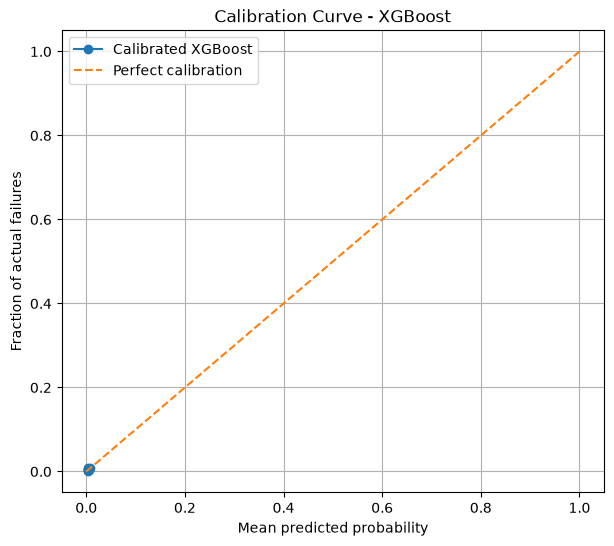

In [28]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_validation,
    calibrated_xgb_probability,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="Calibrated XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of actual failures")
plt.title("Calibration Curve - XGBoost")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
raw_xgb_probability = (
    best_xgboost.predict_proba(X_validation)[:, 1]
)

raw_xgb_brier = brier_score_loss(
    y_validation,
    raw_xgb_probability
)

calibrated_xgb_brier = brier_score_loss(
    y_validation,
    calibrated_xgb_probability
)

brier_comparison = pd.DataFrame([
    {
        "Model": "Raw XGBoost",
        "Brier_Score": raw_xgb_brier
    },
    {
        "Model": "Calibrated XGBoost",
        "Brier_Score": calibrated_xgb_brier
    }
])

brier_comparison

,Model,Brier_Score
0,Raw XGBoost,0.03800
1,Calibrated XGBoost,0.00464


In [30]:
!pip install shap

In [31]:
import shap
import matplotlib.pyplot as plt

In [32]:
shap_explainer = shap.TreeExplainer(
    best_xgboost
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [33]:
X_shap = X_validation.sample(
    n=min(1000, len(X_validation)),
    random_state=42
)

shap_values = shap_explainer.shap_values(
    X_shap
)

print("SHAP values calculated successfully.")
print("Shape:", shap_values.shape)

SHAP values calculated successfully.
Shape: (1000, 8)


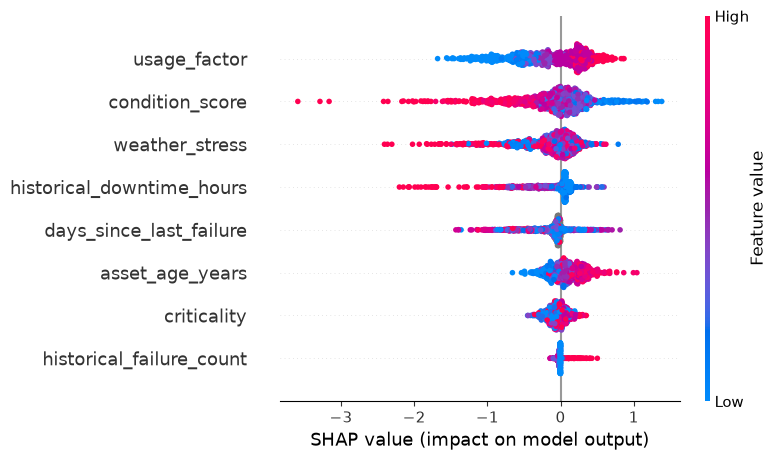

In [34]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

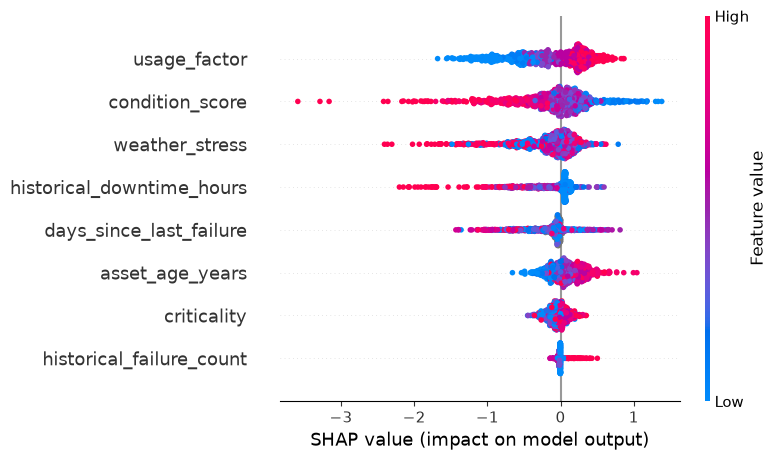

In [35]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../data/predictions/shap_summary_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
validation_probabilities = (
    best_xgboost.predict_proba(X_validation)[:, 1]
)

highest_risk_position = np.argmax(
    validation_probabilities
)

highest_risk_index = X_validation.index[
    highest_risk_position
]

highest_risk_asset = validation.loc[
    highest_risk_index
]

print("Highest-risk asset:")
print(
    highest_risk_asset[
        [
            "asset_id",
            "section_id",
            "department",
            "asset_type"
        ]
    ]
)

print(
    "\nPredicted failure probability:",
    validation_probabilities[highest_risk_position]
)

Highest-risk asset:
asset_id       ASSET00468
section_id     MTJ-AGC-01
department    ENGINEERING
asset_type        TURNOUT
Name: 5604, dtype: object

Predicted failure probability: 0.74013394


In [37]:
print(
    highest_risk_asset[
        feature_columns
    ]
)

asset_age_years                     11
condition_score              63.761827
criticality                          5
usage_factor                  0.909819
weather_stress                0.028301
historical_failure_count             1
historical_downtime_hours     9.403912
days_since_last_failure           92.0
Name: 5604, dtype: object


In [38]:
X_one = X_validation.loc[
    [highest_risk_index]
]

shap_one = shap_explainer(
    X_one
)

print("Individual SHAP explanation created successfully.")

Individual SHAP explanation created successfully.


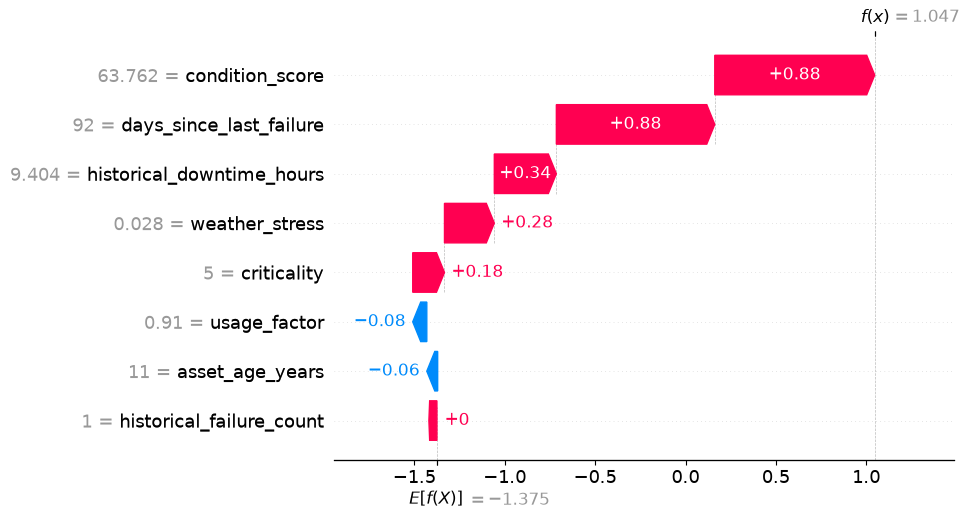

In [39]:
shap.plots.waterfall(
    shap_one[0],
    max_display=8
)

In [40]:
explanation_df = pd.DataFrame({
    "Feature": feature_columns,
    "Feature_Value": X_one.iloc[0].values,
    "SHAP_Value": shap_one.values[0]
})

explanation_df["Absolute_SHAP"] = (
    explanation_df["SHAP_Value"].abs()
)

explanation_df = explanation_df.sort_values(
    "Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

explanation_df

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,condition_score,63.761827,0.884784,0.884784
1,days_since_last_failure,92.000000,0.876379,0.876379
2,historical_downtime_hours,9.403912,0.343199,0.343199
3,weather_stress,0.028301,0.275672,0.275672
4,criticality,5.000000,0.175645,0.175645
5,usage_factor,0.909819,-0.077892,0.077892
6,asset_age_years,11.000000,-0.060071,0.060071
7,historical_failure_count,1.000000,0.004153,0.004153


In [41]:
import json

with open(
    "../models/tuned_xgboost_params.json",
    "w"
) as f:
    json.dump(
        study_xgboost.best_params,
        f,
        indent=4
    )

print("Tuned XGBoost parameters saved.")

Tuned XGBoost parameters saved.


In [42]:
import joblib

joblib.dump(
    calibrated_xgboost,
    "../models/calibrated_xgboost.pkl"
)

print("Calibrated XGBoost model saved.")

Calibrated XGBoost model saved.
